In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np


In [46]:
from torchvision.models.feature_extraction import get_graph_node_names

backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

train_nodes, eval_nodes = get_graph_node_names(backbone)
print("Trainable nodes:\n", train_nodes)  # first 50
print("Eval nodes:\n", eval_nodes)

Trainable nodes:
 ['x', 'features.0', 'features.1.block.0', 'features.1.block.1', 'features.1.block.2', 'features.2.block.0', 'features.2.block.1', 'features.2.block.2', 'features.3.block.0', 'features.3.block.1', 'features.3.block.2', 'features.3.add', 'features.4.block.0', 'features.4.block.1', 'features.4.block.2', 'features.4.block.3', 'features.5.block.0', 'features.5.block.1', 'features.5.block.2', 'features.5.block.3', 'features.5.add', 'features.6.block.0', 'features.6.block.1', 'features.6.block.2', 'features.6.block.3', 'features.6.add', 'features.7.block.0', 'features.7.block.1', 'features.7.block.2', 'features.7.block.3', 'features.8.block.0', 'features.8.block.1', 'features.8.block.2', 'features.8.block.3', 'features.8.add', 'features.9.block.0', 'features.9.block.1', 'features.9.block.2', 'features.9.block.3', 'features.10.block.0', 'features.10.block.1', 'features.10.block.2', 'features.10.block.3', 'features.10.add', 'features.11.block.0', 'features.11.block.1', 'featur

In [4]:
# load pretrained MobileNetV3-Small
backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1).eval()

# we’ll extract some intermediate layers by name
return_nodes = {
    "features.0": "stem",  # very first conv layer
    "features.2.block.0": "early",  # early bottleneck conv
    "features.6.block.0": "mid",  # mid-level
    "features.10.block.0": "late",  # deeper stage
    "features.12": "final",  # last conv stage before pooling/classifier
}

feature_extractor = create_feature_extractor(backbone, return_nodes=return_nodes)

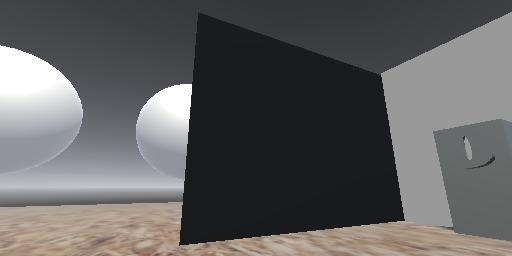

In [6]:
# make a dummy observation: (batch=1, channels=3, height=512, width=256)
from PIL import Image

# path to your visual observation image
img_path = "./obs_step.jpg"  # <-- replace with your file
img = Image.open(img_path).convert("RGB")
img

In [7]:
import torchvision.transforms as T

preprocess = T.Compose(
    [
        T.ToTensor(),  # (H, W, C) [0,1] -> (C, H, W)
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

obs = preprocess(img).unsqueeze(0)  # add batch dim: (1,3,H,W)
print("Obs shape:", obs.shape)

# same normalization as your Extractor
preprocess = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
obs = preprocess(obs)

Obs shape: torch.Size([1, 3, 256, 512])


In [8]:
with torch.no_grad():
    feats = feature_extractor(obs)

for k, v in feats.items():
    print(f"{k}: shape={v.shape}")

stem: shape=torch.Size([1, 16, 128, 256])
early: shape=torch.Size([1, 72, 64, 128])
mid: shape=torch.Size([1, 240, 16, 32])
late: shape=torch.Size([1, 576, 8, 16])
final: shape=torch.Size([1, 576, 8, 16])


In [9]:
def plot_feature_maps(feat_tensor, num_channels=6, title=""):
    """
    feat_tensor: torch.Tensor (1, C, H, W)
    num_channels: how many channels to show
    """
    feat_tensor = feat_tensor.squeeze(0)  # remove batch
    C = feat_tensor.shape[0]
    num_channels = min(num_channels, C)

    fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
    for i in range(num_channels):
        fm = feat_tensor[i].cpu().numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)  # normalize [0,1]
        axes[i].imshow(fm, cmap="viridis")
        axes[i].axis("off")
        axes[i].set_title(f"ch {i}")
    plt.suptitle(title)
    plt.show()

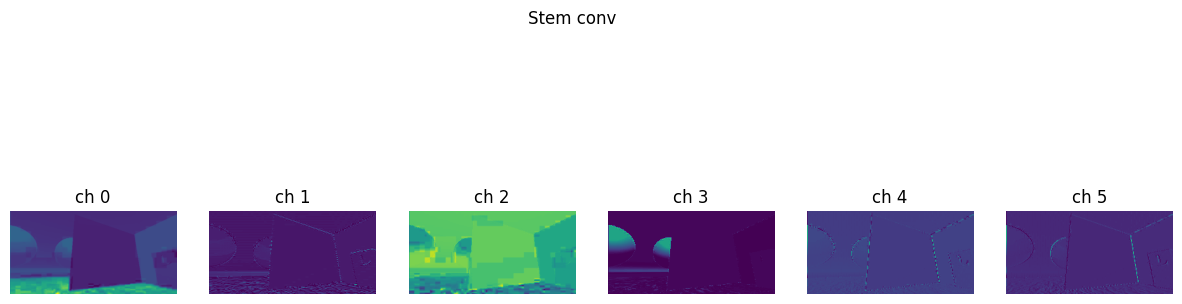

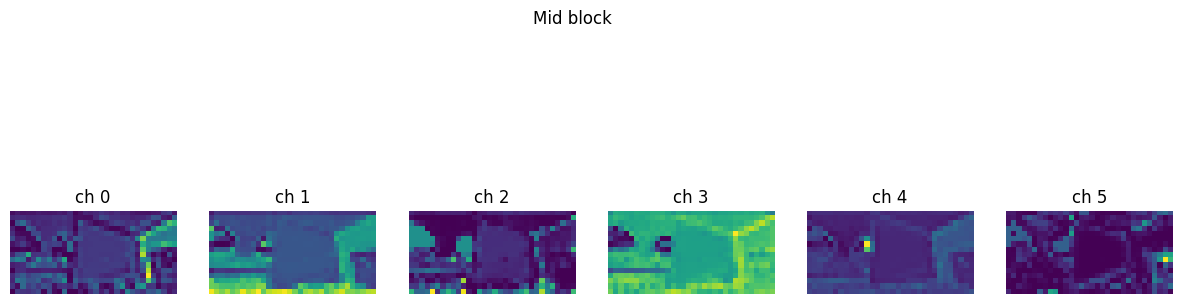

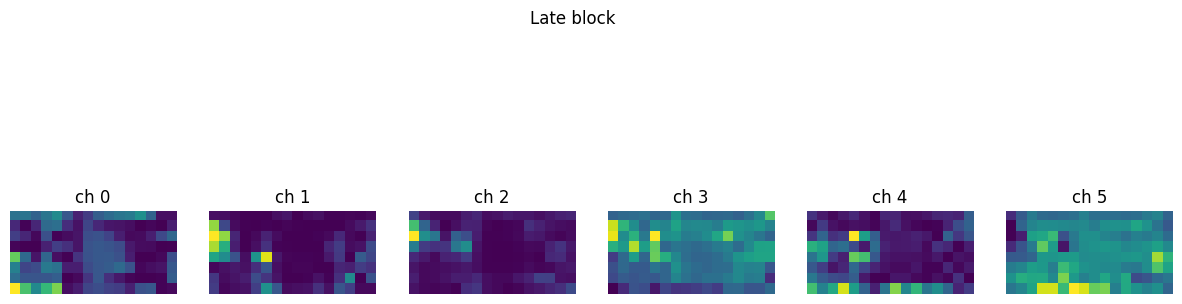

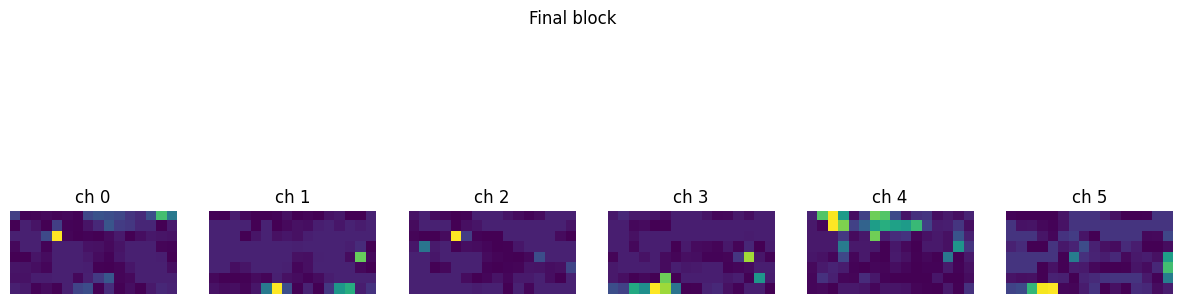

In [ ]:
plot_feature_maps(feats["stem"], title="Stem conv")
# plot_feature_maps(feats["early"], title="Early block")
plot_feature_maps(feats["mid"], title="Mid block")
# plot_feature_maps(feats["late"], title="Late block")
plot_feature_maps(feats["final"], title="Final block")

471 414 59 96
0 414 59 96
147 64 236 255


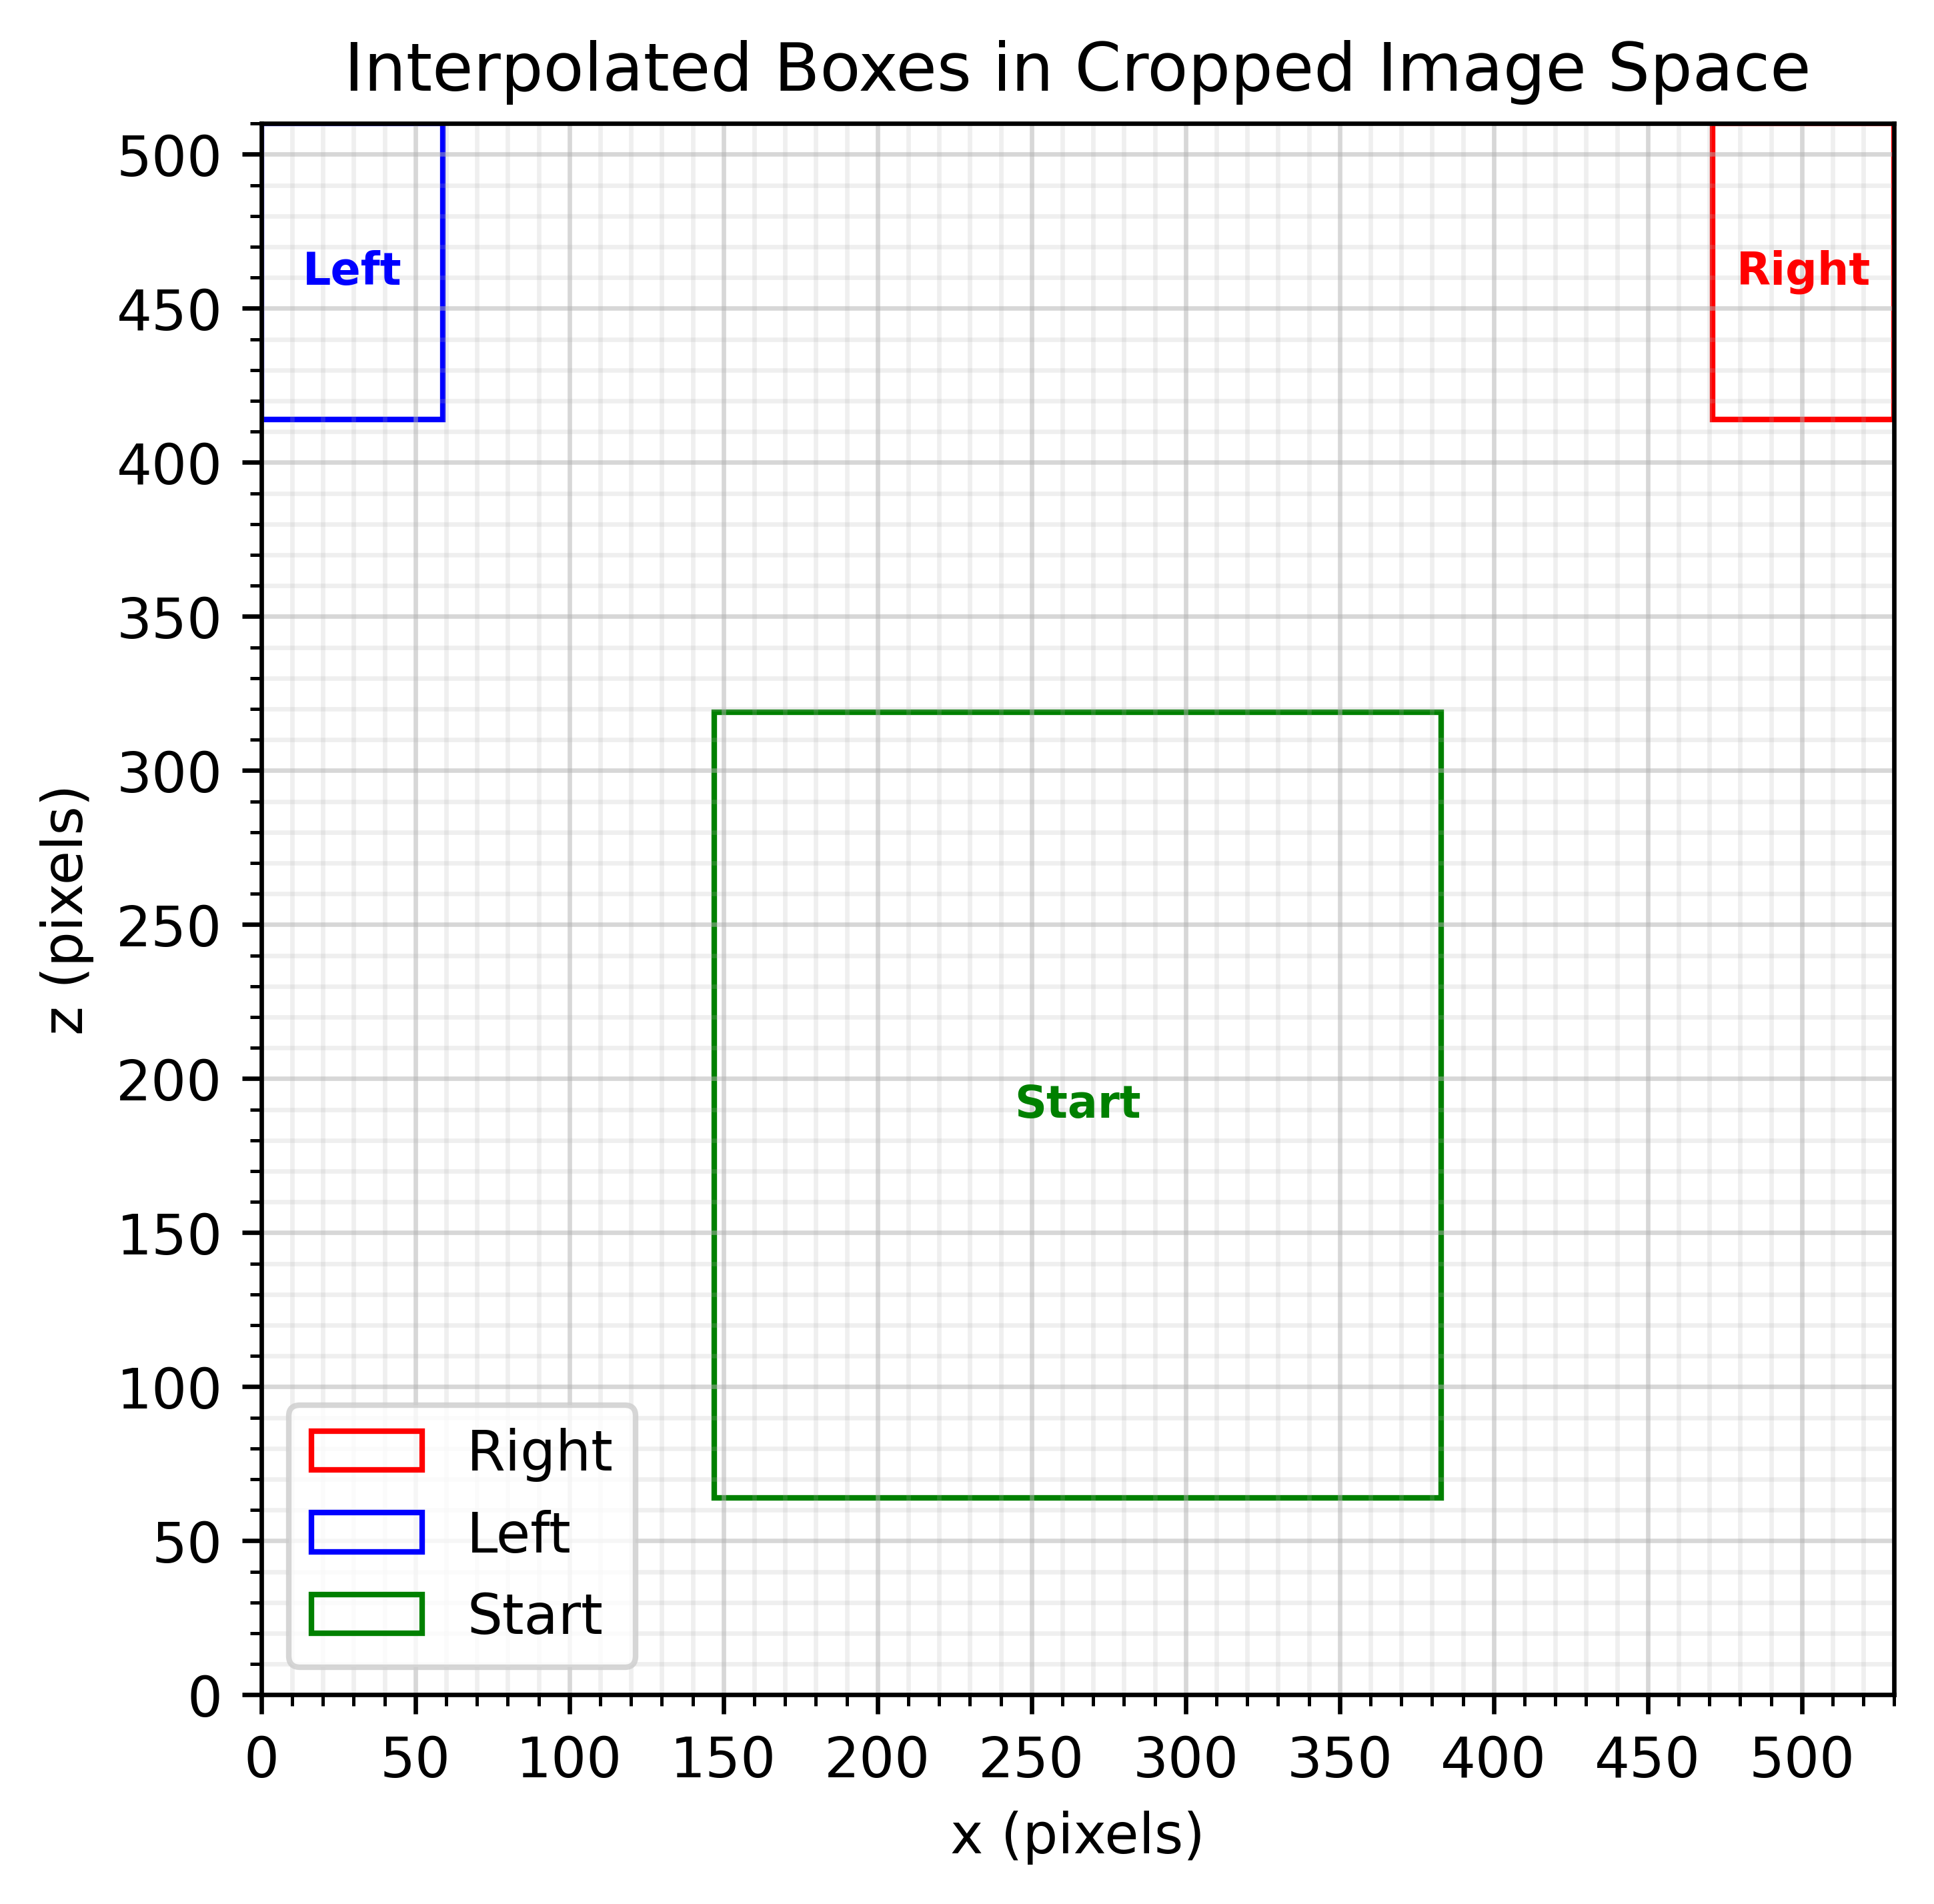

In [64]:
cropped_image = [0, 530, 0, 510]
unity_arena_size = [-9, 9, -10, -2]
r_report_box = [7, 9, -3.5, -2]
l_report_box = [-9, -7, -3.5, -2]
start_box = [-4, 4, -9, -5]

def _change_space(self, x, z, space1, space2):
    # Interpolate input coordinates from space 1 to space 2
    v_x0, v_x1, v_z0, v_z1 = space1
    u_x0, u_x1, u_z0, u_z1 = space2

    x_v, z_v = x, z

    x_u = np.interp(x_v, [v_x0, v_x1], [u_x0, u_x1])
    z_u = np.interp(z_v, [v_z0, v_z1], [u_z0, u_z1])

    return np.array([x_u, z_u])


import matplotlib.pyplot as plt
import numpy as np

# Remove the 5th element from start_box if present (angle)
if len(start_box) == 5:
    start_box = start_box[:4]

def interpolate_box(box, from_space, to_space):
    # box: [x0, x1, z0, z1]
    # returns: [[x0', z0'], [x1', z1']]
    p0 = _change_space(None, box[0], box[2], from_space, to_space)
    p1 = _change_space(None, box[1], box[3], from_space, to_space)
    # Return as [x0', z0', x1', z1']
    return [p0[0], p0[1], p1[0], p1[1]]

cropped_space = cropped_image
unity_space = unity_arena_size

def box_to_rect_coords(box, from_space, to_space):
    # Interpolate corners
    # box: [x0, x1, z0, z1]
    p0 = _change_space(None, box[0], box[2], from_space, to_space)  # (x0, z0)
    p1 = _change_space(None, box[1], box[3], from_space, to_space)  # (x1, z1)
    # Rectangle: left, top, width, height
    left = p0[0]
    right = p1[0]
    top = p0[1]
    bottom = p1[1]
    # Ensure left < right, top < bottom
    x0, x1 = sorted([left, right])
    y0, y1 = sorted([top, bottom])
    width = x1 - x0
    height = y1 - y0
    return x0, y0, width, height

fig, ax = plt.subplots(figsize=(5.3, 5.1), dpi=600)
ax.set_xlim(0, 530)
ax.set_ylim(0, 510)
ax.set_aspect('equal')
# ax.invert_yaxis()  # So (0,0) is top-left like image

# Plot rectangles
for box, color, label in [
    (r_report_box, 'red', 'Right'),
    (l_report_box, 'blue', 'Left'),
    (start_box, 'green', 'Start')
]:
    x, y, w, h = map(lambda v: int(round(v)), box_to_rect_coords(box, unity_space, cropped_space))
    # x, y, w, h = box_to_rect_coords(box, unity_space, cropped_space)
    print(x, y, w, h)
    rect = plt.Rectangle((x, y), w, h, linewidth=1, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)
    # Optionally, add label at center
    ax.text(x + w/2, y + h/2, label, color=color, ha='center', va='center', fontsize=8, weight='bold')

ax.set_title("Interpolated Boxes in Cropped Image Space")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("z (pixels)")
ax.legend()

ax.set_xticks(np.arange(0, 531, 50))
ax.set_yticks(np.arange(0, 511, 50))
ax.set_xticks(np.arange(0, 531, 10), minor=True)
ax.set_yticks(np.arange(0, 511, 10), minor=True)
ax.grid(True, which='major', alpha=0.5)
ax.grid(True, which='minor', alpha=0.2)

plt.show()

In [ ]:
# FreelyMovingVR4Mice/dj_pipeline/vr4mice/analysis/analysis.py

unity_to_physical_arena_size = dict(
	unity_arena_size_x_min=9,
	unity_arena_size_z_max=-10,
	unity_arena_size_z_min=-2,
	physical_arena_size=27,
)

x = np.interp(
	xcoo,
	[
		-1 * unity_to_physical_arena_size["unity_arena_size_x_min"],
		unity_to_physical_arena_size["unity_arena_size_x_min"],
	],
	[
		-1 * unity_to_physical_arena_size["physical_arena_size"],
		unity_to_physical_arena_size["physical_arena_size"],
	],
)
y = np.interp(
	ycoo,
	[
		unity_to_physical_arena_size["unity_arena_size_z_max"],
		unity_to_physical_arena_size["unity_arena_size_z_min"],
	],
	[
		-1 * unity_to_physical_arena_size["physical_arena_size"],
		unity_to_physical_arena_size["physical_arena_size"],
	],
)

In [55]:
from rl_task.utils.feature_extractor import Extractor
from gymnasium import spaces
import torch

C, H, W = 3, 256, 512

dummy = torch.zeros(1, C, H, W)
ext = Extractor(
    observation_space=spaces.Box(low=0, high=255, shape=(C, H, W), dtype=np.uint8)
)
ext.features_dim

576

In [56]:
ext.forward(dummy).shape

torch.Size([1, 576])

In [6]:
from rl_task.config.config import load_config
from rl_task.fake_teensy import FakeTeensy

cfg = load_config(
    preset_name="shape_discrim_multi_occluders",
    yaml_path="/app/rl_task/config/rl_experiments.yaml",
    env_path="/app/rl_task",
    teensy=FakeTeensy(),
    fps=50,
    base_port=5004,
    worker_id=0,
    batchmode=True,
    save_data=False,
)

In [ ]:
cfg.as_kwargs()